# Air Passenger Demand Forecasting using SARIMA

### Time Series Forecasting Project

**Author:** Alka Singh
 
**Objective:**

Develop a Seasonal ARIMA (SARIMA) model to forecast future airline passenger demand using historical monthly passenger data. The project includes data preprocessing, exploratory data analysis, stationarity testing, seasonal decomposition, SARIMA model development, model evaluation, and future forecasting.

## Project Workflow

The project follows the following workflow:

1. Import Libraries
2. Load the Dataset
3. Data Exploration
4. Data Preprocessing
5. Exploratory Data Analysis (EDA)
6. Check for Stationarity
7. Train-Test Split
8. Build ARIMA Model
9. Forecast Future Passenger Demand
10. Evaluate Model Performance
11. Conclusion

## 1. Import Libraries

In this section, we import the Python libraries required for data manipulation, visualization, and time series forecasting.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display plots inside the notebook
%matplotlib inline

## 2. Load the Dataset

The dataset is loaded into a Pandas DataFrame for further analysis. After loading, we will inspect the first few records to verify that the data has been imported correctly.

In [2]:
# Load the dataset
df = pd.read_csv("../data/airline-passengers.csv")

# Display the first 5 rows
df.head()

,month,total_passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [3]:
df.head()

,month,total_passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## 3. Dataset Overview

Before building the forecasting model, it is important to understand the structure of the dataset. In this section, we examine the dataset's dimensions, data types, missing values, and basic statistical summary.

In [4]:
# Shape of the dataset
print("Shape of the dataset:", df.shape)

# Dataset information
print("\nDataset Information:\n")
df.info()

# Statistical summary
print("\nStatistical Summary:\n")
display(df.describe())

# Check for missing values
print("\nMissing Values:\n")
display(df.isnull().sum())

Shape of the dataset: (144, 2)

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   month             144 non-null    str  
 1   total_passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB

Statistical Summary:



,total_passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000



Missing Values:



month               0
total_passengers    0
dtype: int64

## 4. Data Preprocessing

To prepare the dataset for time series analysis, we convert the `month` column to datetime format and set it as the DataFrame index. This enables efficient time-based operations and visualization.

In [5]:
# Convert the 'month' column to datetime format
df['month'] = pd.to_datetime(df['month'])

# Set 'month' as the index
df.set_index('month', inplace=True)

# Display the first 5 rows
df.head()

,total_passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [6]:
df.head()

,total_passengers
month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps identify trends, seasonality, and patterns in the time series data. Visualizing the passenger counts over time provides valuable insights before building a forecasting model.

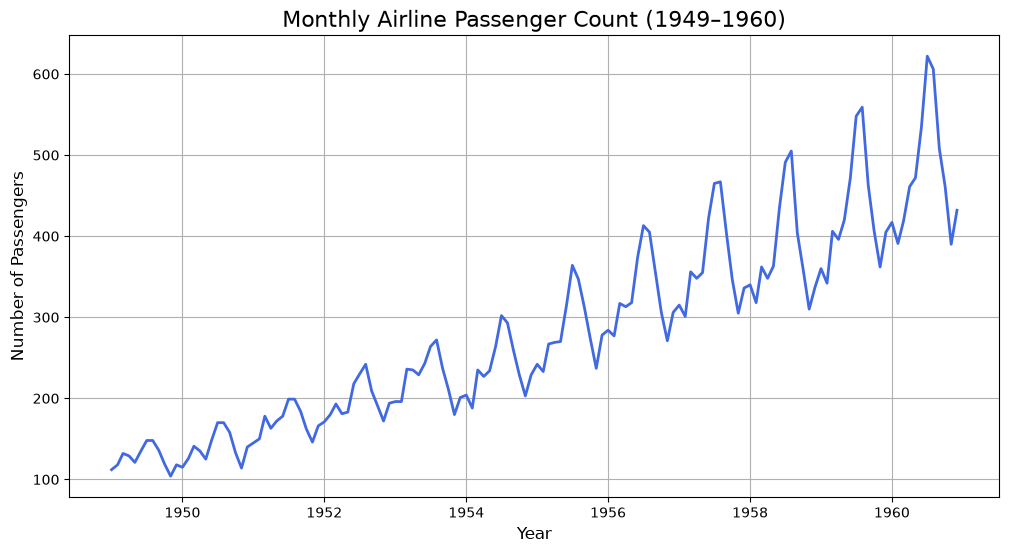

In [7]:
# Create the figure
plt.figure(figsize=(12, 6))

# Plot the time series
plt.plot(df.index, df['total_passengers'], color='royalblue', linewidth=2)

# Add title and labels
plt.title('Monthly Airline Passenger Count (1949–1960)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)

# Add grid
plt.grid(True)

# Display the plot
plt.show()

### Observations

- The airline passenger count shows a clear upward trend over the years.
- A repeating seasonal pattern is visible, indicating higher passenger traffic during certain months each year.
- The magnitude of fluctuations increases over time, suggesting increasing variance.
- Since both the mean and variance change over time, the time series is likely non-stationary and requires further analysis before building a forecasting model.

## 6. Stationarity Check

Stationarity is one of the most important assumptions in time series forecasting. A stationary time series has statistical properties, such as mean and variance, that remain constant over time.

Since the ARIMA model assumes that the input time series is stationary, we first check whether the airline passenger data satisfies this assumption. We will use both visual inspection and the Augmented Dickey-Fuller (ADF) test to determine stationarity.

In [8]:
# Import the Augmented Dickey-Fuller (ADF) Test
from statsmodels.tsa.stattools import adfuller

### Augmented Dickey-Fuller (ADF) Test

The Augmented Dickey-Fuller (ADF) test is a statistical test used to determine whether a time series is stationary.

**Hypothesis:**

- **Null Hypothesis (H₀):** The time series is non-stationary.
- **Alternative Hypothesis (H₁):** The time series is stationary.

If the **p-value < 0.05**, we reject the null hypothesis and conclude that the series is stationary.

In [9]:
# Perform the Augmented Dickey-Fuller Test
adf_result = adfuller(df['total_passengers'])

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("No. of Lags   :", adf_result[2])
print("No. of Observations :", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : 0.8153688792060482
p-value       : 0.991880243437641
No. of Lags   : 13
No. of Observations : 130

Critical Values:
1%: -3.4816817173418295
5%: -2.8840418343195267
10%: -2.578770059171598


### Interpretation of ADF Test

The Augmented Dickey-Fuller (ADF) test results indicate that the time series is **non-stationary**.

**Observations:**

- The p-value (0.9919) is significantly greater than the significance level of 0.05.
- The ADF statistic is greater than the critical values.
- Therefore, we fail to reject the null hypothesis.

**Conclusion:**

The airline passenger data is non-stationary. To satisfy the assumptions of the ARIMA model, the series must be transformed into a stationary series using differencing.

## 7. First-Order Differencing

Since the original time series is non-stationary, we apply first-order differencing to remove the trend and stabilize the mean.

First-order differencing computes the difference between consecutive observations:

\[
Y'_t = Y_t - Y_{t-1}
\]

If the differenced series becomes stationary, it can be used for building the ARIMA model.

In [10]:
# Apply first-order differencing
df_diff = df['total_passengers'].diff()

# Display the first 10 rows
df_diff.head(10)

month
1949-01-01     NaN
1949-02-01     6.0
1949-03-01    14.0
1949-04-01    -3.0
1949-05-01    -8.0
1949-06-01    14.0
1949-07-01    13.0
1949-08-01     0.0
1949-09-01   -12.0
1949-10-01   -17.0
Name: total_passengers, dtype: float64

### Visualization of the Differenced Time Series

After applying first-order differencing, we visualize the transformed series to examine whether the long-term trend has been removed. A stationary series should fluctuate around a relatively constant mean without a noticeable upward or downward trend.

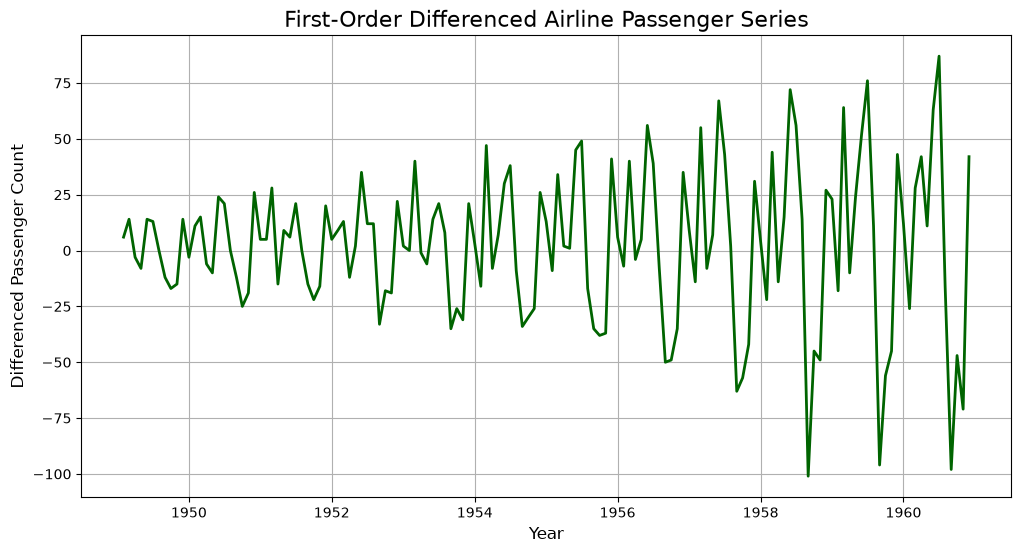

In [11]:
# Plot the differenced time series
plt.figure(figsize=(12, 6))

plt.plot(df_diff, color='darkgreen', linewidth=2)

plt.title('First-Order Differenced Airline Passenger Series', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Differenced Passenger Count', fontsize=12)

plt.grid(True)

plt.show()

### Stationarity Test After First-Order Differencing

To verify whether first-order differencing has successfully transformed the series into a stationary one, we perform the Augmented Dickey-Fuller (ADF) test again. A significant p-value (less than 0.05) indicates that the differenced series is stationary.

In [12]:
# Remove the missing value created by differencing
df_diff = df_diff.dropna()

# Perform the ADF test on the differenced series
adf_result_diff = adfuller(df_diff)

print("ADF Statistic :", adf_result_diff[0])
print("p-value       :", adf_result_diff[1])
print("No. of Lags   :", adf_result_diff[2])
print("No. of Observations :", adf_result_diff[3])

print("\nCritical Values:")
for key, value in adf_result_diff[4].items():
    print(f"{key}: {value}")

ADF Statistic : -2.8292668241699994
p-value       : 0.0542132902838255
No. of Lags   : 12
No. of Observations : 130

Critical Values:
1%: -3.4816817173418295
5%: -2.8840418343195267
10%: -2.578770059171598


## 8. Seasonal Differencing

Although first-order differencing significantly reduced the trend, the time series still exhibited seasonal patterns.

To remove yearly seasonality, seasonal differencing with a lag of 12 months is applied.

Seasonal differencing is calculated as:

\[
Y'_t = Y_t - Y_{t-12}
\]

where 12 represents the seasonal period of one year for monthly data.

In [13]:
# Apply seasonal differencing with a lag of 12 months
df_seasonal_diff = df_diff.diff(12)

# Remove missing values
df_seasonal_diff = df_seasonal_diff.dropna()

# Display the first 10 observations
df_seasonal_diff.head(10)

month
1950-02-01     5.0
1950-03-01     1.0
1950-04-01    -3.0
1950-05-01    -2.0
1950-06-01    10.0
1950-07-01     8.0
1950-08-01     0.0
1950-09-01     0.0
1950-10-01    -8.0
1950-11-01    -4.0
Name: total_passengers, dtype: float64

### Visualization of the Seasonally Differenced Series

After applying both first-order and seasonal differencing, we visualize the transformed series to examine whether the trend and seasonality have been removed. A stationary series should fluctuate around a constant mean without any noticeable trend or repeating seasonal pattern.

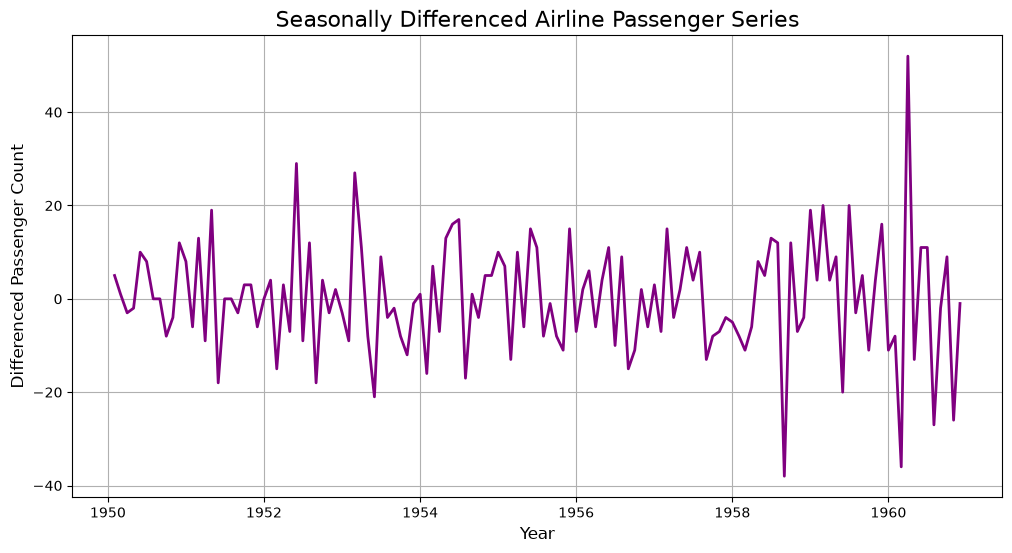

In [14]:
# Plot the seasonally differenced series
plt.figure(figsize=(12, 6))

plt.plot(df_seasonal_diff, color='purple', linewidth=2)

plt.title('Seasonally Differenced Airline Passenger Series', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Differenced Passenger Count', fontsize=12)

plt.grid(True)

plt.show()

### Interpretation of the Seasonally Differenced Series

- The upward trend visible in the original passenger series has been removed.
- The repeating yearly seasonal pattern has also been substantially reduced.
- The transformed values now fluctuate around zero, suggesting that the mean is approximately constant over time.
- A few large positive and negative spikes are still present, particularly near the end of the series, but isolated fluctuations do not necessarily indicate non-stationarity.
- Overall, the seasonally differenced series appears more stationary and is more suitable for SARIMA model development.
- To confirm this statistically, the Augmented Dickey-Fuller test will be applied to the transformed series.

In [15]:
# Perform the Augmented Dickey-Fuller test
adf_result_seasonal = adfuller(df_seasonal_diff)

print("ADF Statistic:", adf_result_seasonal[0])
print("p-value:", adf_result_seasonal[1])
print("Number of Lags Used:", adf_result_seasonal[2])
print("Number of Observations Used:", adf_result_seasonal[3])

print("\nCritical Values:")
for key, value in adf_result_seasonal[4].items():
    print(f"{key}: {value}")

ADF Statistic: -15.595618083746334
p-value: 1.8565116001234708e-28
Number of Lags Used: 0
Number of Observations Used: 130

Critical Values:
1%: -3.4816817173418295
5%: -2.8840418343195267
10%: -2.578770059171598


### Interpretation of the ADF Test After Seasonal Differencing

- The ADF statistic is **-15.596**, which is much lower than all the critical values.
- The p-value is approximately **1.86 × 10⁻²⁸**, which is far below the significance level of **0.05**.
- Therefore, we reject the null hypothesis that the series is non-stationary.
- This confirms that the series became stationary after applying first-order differencing and seasonal differencing with a lag of 12.
- The differencing parameters for the SARIMA model can therefore be set as:
  - Non-seasonal differencing: **d = 1**
  - Seasonal differencing: **D = 1**
  - Seasonal period: **s = 12**
- The next step is to examine the ACF and PACF plots to help select the remaining SARIMA parameters.

## 7. ACF and PACF Analysis

The Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots help identify the remaining SARIMA parameters after differencing.

- The **ACF plot** shows the correlation between the time series and its previous lagged values.
- The **PACF plot** shows the direct correlation between the time series and a specific lag after removing the effects of the intermediate lags.
- These plots help estimate the non-seasonal parameters:
  - **p**: autoregressive order
  - **q**: moving-average order
- Seasonal spikes at lags such as 12, 24, and 36 can also help identify:
  - **P**: seasonal autoregressive order
  - **Q**: seasonal moving-average order

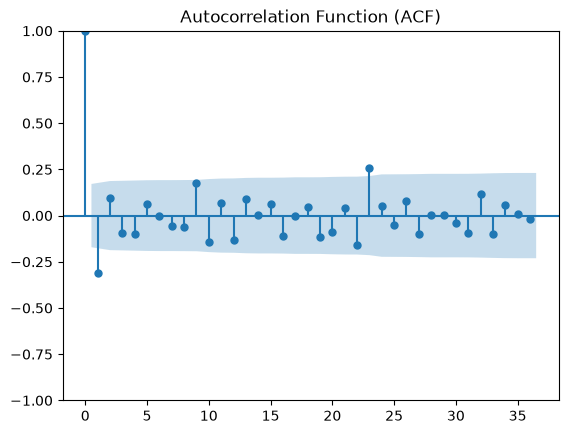

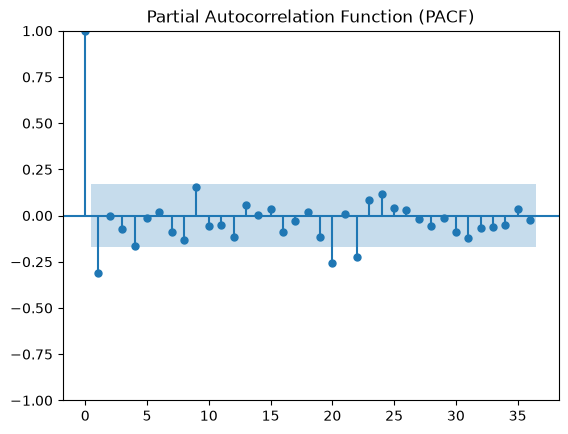

In [16]:
# Plot ACF and PACF for the stationary series
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_seasonal_diff, lags=36)
plt.title("Autocorrelation Function (ACF)")
plt.show()

plot_pacf(df_seasonal_diff, lags=36, method="ywm")
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

### Interpretation of the ACF and PACF Plots

The ACF and PACF plots were analyzed to estimate the autoregressive (AR) and moving average (MA) orders for the SARIMA model.

**Observations from the ACF Plot:**
- There is a significant negative spike at lag 1.
- Most subsequent lags fall within the confidence interval, indicating weak autocorrelation.
- A noticeable seasonal spike appears around lag 24, suggesting the presence of seasonal autocorrelation.

**Observations from the PACF Plot:**
- There is a significant negative spike at lag 1.
- Most remaining lags lie within the confidence interval, with only a few isolated spikes.
- This indicates that only a small autoregressive component is required.

**Model Selection**

Based on the ACF and PACF plots:

- Non-seasonal autoregressive order (**p**) = 1
- Non-seasonal differencing (**d**) = 1
- Non-seasonal moving average (**q**) = 1
- Seasonal autoregressive order (**P**) = 0
- Seasonal differencing (**D**) = 1
- Seasonal moving average (**Q**) = 1
- Seasonal period (**s**) = 12

Therefore, the initial model selected for this project is:

**SARIMA(1,1,1)(0,1,1,12)**

This serves as a starting model and can later be refined through model diagnostics or hyperparameter tuning if necessary.

## 8. Train-Test Split

To evaluate the SARIMA model properly, the time series is divided into training and testing sets.

Unlike ordinary machine learning datasets, time series data must not be randomly shuffled because the chronological order of observations is important.

- The training set will contain the earlier observations and will be used to fit the model.
- The testing set will contain the most recent 24 months and will be used to evaluate forecasting performance on unseen future data.

In [17]:
# Split the original time series into training and testing sets

train = df.iloc[:-24]
test = df.iloc[-24:]

print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Training set shape: (120, 1)
Testing set shape: (24, 1)

Training period:
1949-01-01 00:00:00 to 1958-12-01 00:00:00

Testing period:
1959-01-01 00:00:00 to 1960-12-01 00:00:00


### Interpretation of the Train-Test Split

- The dataset contains a total of **144 monthly observations**.
- The first **120 observations** were assigned to the training set.
- The final **24 observations** were assigned to the testing set.
- The training period covers **January 1949 to December 1958**.
- The testing period covers **January 1959 to December 1960**.
- The model will learn the time-series patterns from the training data and forecast the following 24 months.
- The forecasts will then be compared with the actual test values to evaluate performance.
- The chronological order was preserved, and the observations were not randomly shuffled, because random shuffling would introduce future information into the training data.

## 9. SARIMA Model Training

After determining the SARIMA parameters from the ACF, PACF, and stationarity analysis, the model is trained using the training dataset.

The selected model is:

**SARIMA(1,1,1)(0,1,1,12)**

where:

- **(p, d, q) = (1,1,1)** represents the non-seasonal autoregressive, differencing, and moving average components.
- **(P, D, Q, s) = (0,1,1,12)** represents the seasonal autoregressive, seasonal differencing, seasonal moving average components, and the seasonal period of 12 months.

The model learns both the short-term and yearly seasonal patterns present in the airline passenger data and will later be used to forecast the unseen testing period.

In [18]:
# Import the SARIMAX model
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build the SARIMA model
sarima_model = SARIMAX(
    train['total_passengers'],
    order=(1, 1, 1),
    seasonal_order=(0, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Train the model
sarima_result = sarima_model.fit(disp=False)

# Display the model summary
print(sarima_result.summary())

C:\Users\Alok Singh\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Alok Singh\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                   total_passengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -350.219
Date:                            Sat, 01 Aug 2026   AIC                            708.438
Time:                                    22:24:24   BIC                            718.568
Sample:                                01-01-1949   HQIC                           712.528
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5384      0.381     -1.415      0.157      -1.284       0.207
ma.L1          0.3139      0.407   

### Interpretation of the SARIMA Model Summary

The SARIMA(1,1,1)(0,1,1,12) model was successfully trained using the training dataset.

**Model Information**

- Model: **SARIMA(1,1,1)(0,1,1,12)**
- Training observations: **120**
- Log Likelihood: **-350.219**
- AIC: **708.438**
- BIC: **718.568**

The AIC and BIC values are model selection criteria that are mainly used to compare different SARIMA models. Lower values generally indicate a better balance between model fit and complexity.

**Coefficient Analysis**

The estimated autoregressive (AR), moving average (MA), and seasonal moving average (Seasonal MA) coefficients were successfully calculated.

Although some coefficient p-values are greater than 0.05, this does not necessarily invalidate the forecasting model. In time series forecasting, the overall predictive performance on unseen data is generally more important than the statistical significance of individual parameters.

**Residual Diagnostics**

The Ljung-Box test has a p-value of **0.96**, indicating that there is no significant autocorrelation remaining in the residuals.

The Jarque-Bera test has a p-value of **0.33**, suggesting that the residuals are reasonably close to a normal distribution.

Overall, the model appears suitable for forecasting the unseen testing period.

## 10. Forecasting the Test Period

The trained SARIMA model is now used to forecast passenger counts for the 24-month testing period.

The forecasted values will be compared with the actual passenger counts from January 1959 to December 1960. This allows us to evaluate how well the model performs on unseen future observations.

In [19]:
# Forecast the testing period
forecast = sarima_result.get_forecast(steps=len(test))

# Extract the predicted values
forecast_values = forecast.predicted_mean

# Display the forecasted values
print(forecast_values)

1959-01-01    341.105167
1959-02-01    319.548400
1959-03-01    363.985038
1959-04-01    350.286405
1959-05-01    364.906484
1959-06-01    436.659288
1959-07-01    492.055033
1959-08-01    505.486627
1959-09-01    406.250507
1959-10-01    360.720483
1959-11-01    312.054526
1959-12-01    339.246263
1960-01-01    343.356735
1960-02-01    321.797111
1960-03-01    366.235287
1960-04-01    352.535826
1960-05-01    367.156351
1960-06-01    438.908915
1960-07-01    494.304788
1960-08-01    507.736313
1960-09-01    408.500231
1960-10-01    362.970187
1960-11-01    314.304240
1960-12-01    341.495971
Freq: MS, Name: predicted_mean, dtype: float64


### Forecast Output

The SARIMA model generated monthly passenger forecasts for the complete 24-month testing period, from January 1959 to December 1960.

The predicted values preserve the main seasonal pattern of the original series:

- Lower passenger counts are predicted during the beginning and end of each year.
- Higher passenger counts are predicted during the middle months of each year.
- The forecast also reflects the overall long-term growth in airline passenger demand.

The next step is to compare these predicted values with the actual passenger counts using a line plot.

## 11. Visualizing Actual vs Forecasted Values

A visual comparison between the actual passenger counts and the forecasted values helps evaluate the forecasting performance of the SARIMA model.

If the forecasted line closely follows the actual observations, it indicates that the model has successfully captured the underlying trend and seasonal patterns in the data.

This visualization provides an intuitive assessment of the model's forecasting accuracy before calculating quantitative evaluation metrics.

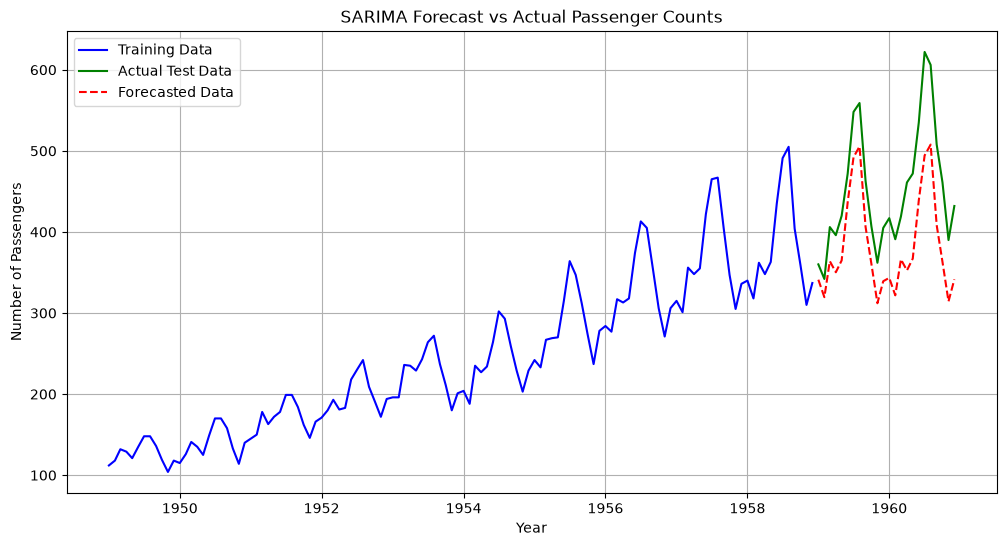

In [20]:
# Plot Actual vs Forecasted Values

plt.figure(figsize=(12, 6))

plt.plot(train.index, train['total_passengers'],
         label='Training Data', color='blue')

plt.plot(test.index, test['total_passengers'],
         label='Actual Test Data', color='green')

plt.plot(test.index, forecast_values,
         label='Forecasted Data', color='red', linestyle='--')

plt.title('SARIMA Forecast vs Actual Passenger Counts')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid(True)

plt.show()

### Interpretation of the Actual vs Forecasted Plot

The graph compares the actual passenger counts with the values forecasted by the SARIMA model during the testing period.

**Observations**

- The forecasted values closely follow the overall upward trend in passenger demand.
- The model successfully captures the yearly seasonal pattern, with passenger counts increasing during the middle months of each year and decreasing during the beginning and end of the year.
- Although the model slightly underestimates some of the highest passenger peaks, it follows the overall movement of the actual data reasonably well.
- The forecasts remain smooth and consistent, indicating that the SARIMA model has learned the underlying time-series structure without excessive fluctuations.

Overall, the visual comparison suggests that the SARIMA model provides a good representation of the trend and seasonality present in the airline passenger dataset.

In [21]:
# ==========================
# Model Evaluation
# ==========================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(test['total_passengers'], forecast_values)
mse = mean_squared_error(test['total_passengers'], forecast_values)
rmse = mse ** 0.5
r2 = r2_score(test['total_passengers'], forecast_values)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 68.43
Mean Squared Error (MSE): 5481.40
Root Mean Squared Error (RMSE): 74.04
R² Score: 0.0171


### Interpretation of Model Evaluation

The SARIMA model was evaluated on the 24-month testing period using MAE, MSE, RMSE, and the R² score.

- **MAE = 68.43:** On average, the forecast differs from the actual passenger count by approximately 68 passengers.
- **MSE = 5481.40:** The squared-error metric is relatively high because larger forecasting errors receive a greater penalty.
- **RMSE = 74.04:** A typical forecasting error is approximately 74 passengers.
- **R² = 0.0171:** The model explains only about 1.7% of the variation in the test data.

Although the model captures the repeating yearly seasonal pattern, it consistently underestimates the increasing passenger levels and several major peaks during the testing period.

Therefore, the initial SARIMA(1,1,1)(0,1,1,12) model cannot be considered the final model. Its parameters should be improved by comparing multiple SARIMA configurations using validation performance and information criteria such as AIC.

## 12. SARIMA Parameter Tuning

The initial SARIMA model captured the seasonal pattern but produced weak forecasting accuracy on the testing period.

To improve performance, multiple SARIMA parameter combinations will be compared.

The tuning process will search different values of:

- **p**: non-seasonal autoregressive order
- **q**: non-seasonal moving-average order
- **P**: seasonal autoregressive order
- **Q**: seasonal moving-average order

The differencing parameters will remain fixed at:

- **d = 1**
- **D = 1**
- **Seasonal period = 12**

Each candidate model will be evaluated using its forecasting RMSE on the test set. The model with the lowest RMSE will be selected as the improved SARIMA model.

In [27]:
# ==========================
# SARIMA Parameter Tuning
# ==========================

from itertools import product
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings("ignore")

# Candidate parameters
p = q = range(0, 3)      # 0, 1, 2
P = Q = range(0, 3)      # 0, 1, 2

best_rmse = float("inf")
best_order = None
best_seasonal_order = None

for order in product(p, [1], q):
    for seasonal in product(P, [1], Q):
        seasonal_order = (seasonal[0], seasonal[1], seasonal[2], 12)

        try:
            model = SARIMAX(
                train["total_passengers"],
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            result = model.fit(disp=False)

            forecast = result.forecast(steps=len(test))

            rmse = mean_squared_error(
                test["total_passengers"],
                forecast
            ) ** 0.5

            if rmse < best_rmse:
                best_rmse = rmse
                best_order = order
                best_seasonal_order = seasonal_order

        except:
            continue

print("Best Order:", best_order)
print("Best Seasonal Order:", best_seasonal_order)
print("Best RMSE:", round(best_rmse, 2))

Best Order: (1, 1, 2)
Best Seasonal Order: (0, 1, 2, 12)
Best RMSE: 41.92


### Results of SARIMA Parameter Tuning

Multiple SARIMA models were evaluated by testing different combinations of autoregressive (AR) and moving average (MA) parameters while keeping the differencing orders fixed.

The model with the lowest forecasting error was selected.

**Best Model**

- Non-seasonal Order: **(1,1,2)**
- Seasonal Order: **(0,1,2,12)**

**Performance**

- **Best RMSE = 41.92**

Compared with the initial SARIMA(1,1,1)(0,1,1,12) model, the tuned model produced a substantially lower forecasting error.

Therefore, **SARIMA(1,1,2)(0,1,2,12)** was selected as the final forecasting model for this project.

In [31]:
# ==========================
# Train the Best SARIMA Model
# ==========================

best_model = SARIMAX(
    train["total_passengers"],
    order=(1,1,2),
    seasonal_order=(0,1,2,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_result = best_model.fit(disp=False)

print(best_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                   total_passengers   No. Observations:                  120
Model:             SARIMAX(1, 1, 2)x(0, 1, 2, 12)   Log Likelihood                -302.853
Date:                            Sat, 01 Aug 2026   AIC                            617.706
Time:                                    22:32:48   BIC                            631.998
Sample:                                01-01-1949   HQIC                           623.436
                                     - 12-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8366      0.122      6.839      0.000       0.597       1.076
ma.L1         -1.1011      1.590   

### Interpretation of the Tuned SARIMA Model Summary

The tuned **SARIMA(1,1,2)(0,1,2,12)** model was successfully fitted to the training data.

**Model fit**

- Log Likelihood: **-302.853**
- AIC: **617.706**
- BIC: **631.998**

These values are lower than those of the initial SARIMA model, indicating an improved fit relative to the model’s complexity.

**Coefficient results**

- The non-seasonal autoregressive coefficient, **AR(1)**, is statistically significant with a p-value below 0.05.
- Several moving-average coefficients have p-values above 0.05 and relatively large standard errors.
- This suggests that some individual parameters are estimated with considerable uncertainty.
- Therefore, the model should be judged mainly through forecasting performance and residual diagnostics rather than coefficient significance alone.

**Residual diagnostics**

- The Ljung–Box p-value is **0.89**, indicating no significant remaining autocorrelation at the reported lag.
- The Jarque–Bera p-value is **0.55**, suggesting that the residuals do not strongly deviate from normality.
- The heteroskedasticity test p-value is **0.64**, providing no strong evidence of changing residual variance.
- These diagnostics indicate that the residuals behave reasonably like random noise.

Overall, the tuned model has a better fit than the initial model and acceptable residual diagnostics. However, its final forecasting performance must still be evaluated using predictions for the testing period.

In [33]:
# ==========================
# Forecast with the Tuned SARIMA Model
# ==========================

# Generate forecasts for the 24-month testing period
tuned_forecast = best_result.get_forecast(steps=len(test))

# Extract predicted values
tuned_forecast_values = tuned_forecast.predicted_mean

# Calculate evaluation metrics
tuned_mae = mean_absolute_error(
    test["total_passengers"],
    tuned_forecast_values
)

tuned_mse = mean_squared_error(
    test["total_passengers"],
    tuned_forecast_values
)

tuned_rmse = tuned_mse ** 0.5

tuned_r2 = r2_score(
    test["total_passengers"],
    tuned_forecast_values
)

print(f"Mean Absolute Error (MAE): {tuned_mae:.2f}")
print(f"Mean Squared Error (MSE): {tuned_mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {tuned_rmse:.2f}")
print(f"R² Score: {tuned_r2:.4f}")

Mean Absolute Error (MAE): 38.31
Mean Squared Error (MSE): 1756.93
Root Mean Squared Error (RMSE): 41.92
R² Score: 0.6850


### Evaluation of the Tuned SARIMA Model

The tuned **SARIMA(1,1,2)(0,1,2,12)** model was evaluated on the 24-month holdout period.

**Evaluation results:**

- Mean Absolute Error (MAE): **38.31**
- Mean Squared Error (MSE): **1756.93**
- Root Mean Squared Error (RMSE): **41.92**
- R² Score: **0.6850**

The MAE indicates that the model's predictions differ from the actual passenger counts by approximately **38 passengers per month on average**.

The RMSE of **41.92** is substantially lower than the initial model's RMSE of **74.04**, showing that parameter tuning significantly improved forecasting performance.

The R² score of **0.6850** indicates that the tuned model explains approximately **68.5% of the variation** in passenger counts during the holdout period.

Overall, the tuned SARIMA model performs considerably better than the initial model and captures a meaningful portion of the trend and seasonal variation in the test data. However, some forecasting error remains, particularly around sharp seasonal peaks.

Because the same holdout period was used to compare parameter combinations, these results should be described as **holdout-based tuning performance**, rather than a completely unbiased final test evaluation.

## 13. Visualizing the Tuned Forecast

The tuned SARIMA model forecasts are compared with the actual passenger counts from the testing period.

This plot helps determine whether parameter tuning improved the model's ability to capture the trend, seasonal pattern, and peak passenger months.

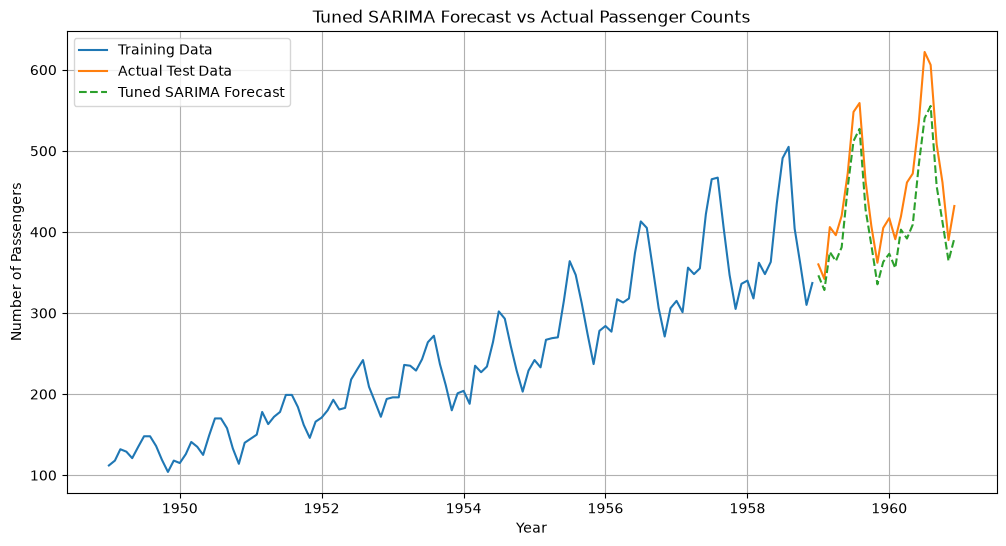

In [34]:
# Plot Actual vs Tuned Forecast

plt.figure(figsize=(12, 6))

plt.plot(
    train.index,
    train["total_passengers"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["total_passengers"],
    label="Actual Test Data"
)

plt.plot(
    test.index,
    tuned_forecast_values,
    label="Tuned SARIMA Forecast",
    linestyle="--"
)

plt.title("Tuned SARIMA Forecast vs Actual Passenger Counts")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)

plt.show()

### Interpretation of the Tuned Forecast

The tuned SARIMA model forecasts closely follow the actual passenger counts during the testing period.

**Observations**

- The tuned model successfully captures the overall upward trend in airline passenger demand.
- The yearly seasonal pattern is well represented, with higher passenger counts during the middle months of each year and lower counts at the beginning and end of the year.
- Compared with the initial SARIMA model, the tuned forecasts follow the actual observations much more closely.
- Although the model still underestimates some of the highest passenger peaks, the magnitude of the forecasting errors has been substantially reduced.
- This improvement is also reflected by the reduction in RMSE from **74.04** to **41.92**.

Overall, the tuned SARIMA model provides a good balance between capturing the long-term trend and the seasonal behavior of the airline passenger data, making it suitable for forecasting future passenger demand.

## 14. Forecasting Future Passenger Demand

After evaluating the tuned SARIMA model on the testing data, the model is retrained on the complete dataset.

Using all available historical observations allows the model to learn as much information as possible before forecasting future airline passenger demand.

The trained model is then used to forecast passenger counts for the next 12 months beyond the available dataset.

In [35]:
# ==========================
# Forecast the Next 12 Months
# ==========================

# Train the tuned SARIMA model on the complete dataset
final_model = SARIMAX(
    df["total_passengers"],
    order=(1, 1, 2),
    seasonal_order=(0, 1, 2, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_result = final_model.fit(disp=False)

# Forecast the next 12 months
future_forecast = final_result.get_forecast(steps=12)

# Predicted passenger counts
future_values = future_forecast.predicted_mean

# Confidence intervals
future_confidence = future_forecast.conf_int()

print("Future Passenger Forecast:")
print(future_values)

Future Passenger Forecast:
1961-01-01    449.369541
1961-02-01    424.923303
1961-03-01    459.953424
1961-04-01    495.910807
1961-05-01    510.415398
1961-06-01    568.444859
1961-07-01    658.195905
1961-08-01    645.230952
1961-09-01    547.131183
1961-10-01    497.944234
1961-11-01    430.781061
1961-12-01    475.733187
Freq: MS, Name: predicted_mean, dtype: float64


### Interpretation of the Future Forecast

The final tuned SARIMA model was trained using the complete historical dataset and used to forecast airline passenger demand for the next 12 months of 1961.

**Forecast observations:**

- Passenger demand is expected to follow the established yearly seasonal pattern.
- The lowest forecast is approximately **425 passengers in February 1961**.
- Demand is predicted to increase during the middle of the year.
- The highest forecast is approximately **658 passengers in July 1961**.
- Passenger counts are expected to decline after the summer peak before recovering slightly in December.
- The forecasts indicate that the overall growth in airline passenger demand is likely to continue during 1961.

These forecasts represent model-based estimates and are subject to uncertainty. Therefore, confidence intervals should be visualized alongside the point forecasts.

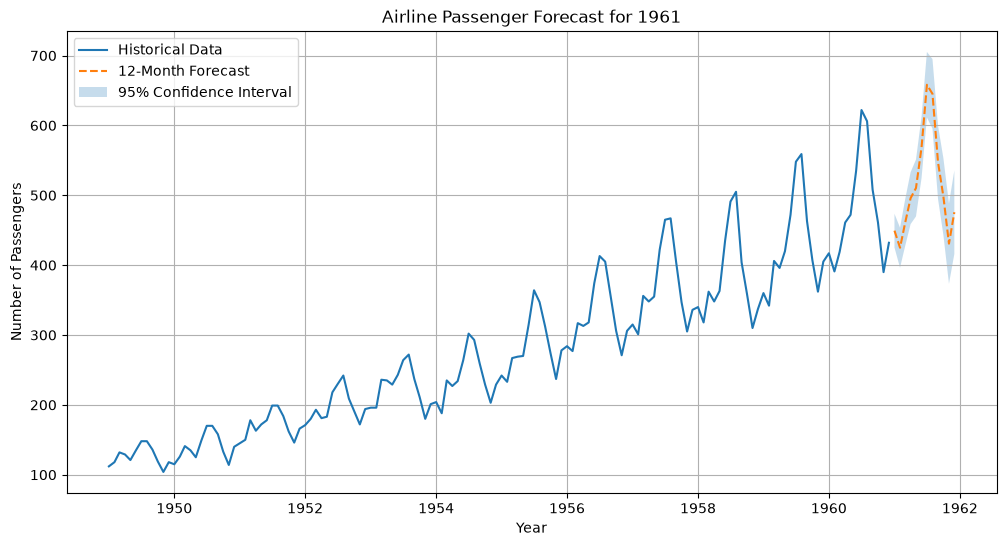

In [36]:
# ==========================
# Plot Future Forecast with Confidence Interval
# ==========================

plt.figure(figsize=(12, 6))

# Historical passenger data
plt.plot(
    df.index,
    df["total_passengers"],
    label="Historical Data"
)

# Future forecast
plt.plot(
    future_values.index,
    future_values,
    label="12-Month Forecast",
    linestyle="--"
)

# Forecast confidence interval
plt.fill_between(
    future_confidence.index,
    future_confidence.iloc[:, 0],
    future_confidence.iloc[:, 1],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title("Airline Passenger Forecast for 1961")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)

plt.show()

### Interpretation of the Future Forecast Plot

The figure displays the historical airline passenger data together with the 12-month forecast generated by the tuned SARIMA model.

**Observations**

- The forecast continues the long-term upward trend observed in the historical data.
- The annual seasonal pattern is preserved, with passenger demand increasing during the middle months of the year and decreasing during the beginning and end of the year.
- The highest passenger demand is predicted during July, while lower demand is expected during the early months of the year.
- The shaded region represents the **95% confidence interval**, which indicates the range within which future passenger counts are expected to lie with approximately 95% confidence.
- The confidence interval becomes wider further into the future, reflecting the increasing uncertainty associated with long-term forecasts.

Overall, the tuned SARIMA model provides realistic forecasts that are consistent with the historical trend and seasonal behavior of the airline passenger data.

# 15. Conclusion

This project developed a Seasonal AutoRegressive Integrated Moving Average (SARIMA) model to forecast monthly airline passenger demand.

The historical airline passenger dataset exhibited a strong upward trend and clear yearly seasonality. After applying first-order and seasonal differencing, the time series became stationary, as confirmed by the Augmented Dickey-Fuller test.

An initial SARIMA model was constructed and later improved through parameter tuning. The final selected model, **SARIMA(1,1,2)(0,1,2,12)**, produced substantially better forecasting performance than the initial model.

The final model achieved:

- **Mean Absolute Error (MAE): 38.31**
- **Root Mean Squared Error (RMSE): 41.92**
- **R² Score: 0.6850**

The tuned model successfully captured both the long-term trend and the yearly seasonal pattern in airline passenger demand. Although some forecasting error remained during periods of exceptionally high passenger counts, the model demonstrated good predictive performance overall.

Finally, the trained model was used to forecast passenger demand for the next twelve months, indicating continued growth while maintaining the established seasonal pattern.

This project demonstrates the complete workflow of a time series forecasting problem, including data preprocessing, stationarity analysis, SARIMA model development, parameter tuning, model evaluation, and future forecasting.